In [1]:
import torch 
import os
import torch.optim
import torch.nn as nn
import torchvision.datasets as dset
from torch.utils.data import dataloader
from torchvision.transforms import transforms
import torchvision.utils as vutils
import numpy as np 
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from timeit import default_timer
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.10.0+cpu
False
None


In [2]:
#Custom anime datasetclass
from torch.utils.data import Dataset
from PIL import Image
import os 

class anime_dataset(Dataset):
    def __init__(self, root , transforms=None):
        self.root = root
        self.image = os.listdir(root)
        self.transforms = transforms

    def __len__(self):
        return(len(self.image))

    def __getitem__(self, idx):
       img_path = os.path.join(self.root, self.image[idx])
       img = Image.open(img_path).convert('RGB')
       if self.transforms:
           img = self.transforms(img)
       return img 

In [3]:
#transform

data_transforms = transforms.Compose([
    transforms.Resize(64),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
])

In [4]:
#dataste and dataloader
data_root = '/kaggle/input/datasets/splcher/animefacedataset/images'
anime_data = anime_dataset(root=data_root, transforms=data_transforms)

anime_dataloader = torch.utils.data.DataLoader(anime_data,
                                               batch_size=64,
                                               shuffle=True,
                                               pin_memory=True,
                                               drop_last=True)

print(f'Total Lenght of dataset:{len(anime_data)}')
print(f'Total lenght of dataloader:{len(anime_dataloader)} ')

Total Lenght of dataset:63565
Total lenght of dataloader:993 


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


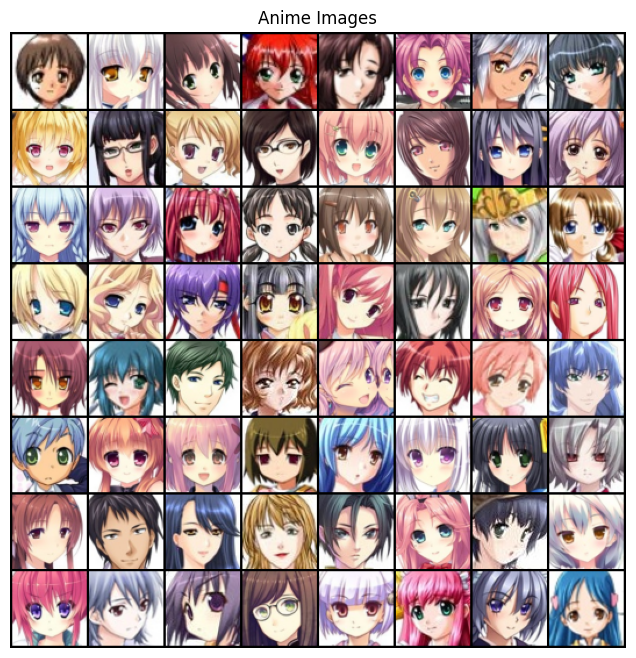

In [5]:
#visualizing dataset
batch = next(iter(anime_dataloader))
plt.figure(figsize=(8,8))
plt.axis('off')
plt.title('Anime Images')
plt.imshow(np.transpose(vutils.make_grid(batch[:64], padding=2, normalize=True).cpu(), (1,2,0)))
plt.show()


In [6]:
#variance schedule
t = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end , steps=t)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [7]:
#forward pass 
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1. - alphas_cumprod[t]).view(-1,1,1,1)

    return sqrt_alphas_cumprod_t * x0 + sqrt_one_minus_alphas_cumprod_t*noise

In [12]:
#device 
device = 'cuda ' if torch.cuda.is_available() else 'cpu'
device 

'cpu'

In [18]:
#SinusoidalPositionEmbeddings
import math
import torch.nn as nn 

class SinusoidalPositionEmbeddings(torch.nn.Module):
    def __init__(self, dim:int):
        super().__init__()
        assert dim % 2 == 0, "Embedding must divisble by 2"
        self.dim = dim 
    
    def forward(self, time_stamps: torch.Tensor) -> torch.Tensor :
        device = time_stamps.device
        half_dim = self.dim // 2
        scale = math.log(10000)/ (half_dim - 1)
        freqs= torch.exp(torch.arange(half_dim, dtype=torch.float32, device=device) * -scale)
        embeddings = time_stamps[:, None].float() * freqs[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings 
        

In [21]:
#time embedding 

class Time_embeddings(torch.nn.Module):
    def __init__(self, time_emb_dim: int, out_dim: int):
        super().__init__()
        self.sinusoidal_emb = SinusoidalPositionEmbeddings(time_emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(time_emb_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim)
        )
    def forward (self, time_steps: torch.Tensor) -> torch.Tensor :
        raw_emb = self.sinusoidal_emb(time_steps)
        return self.mlp(raw_emb)